# 💳  Financial Threat Monitoring Dashboard Using CTGAN

### Project Type
Classification + Generative AI

### Contribution
D Md Khizer Farhaan


## 📌 Project Overview

This project aims to identify fraudulent financial transactions using Machine Learning and CTGAN-generated synthetic fraud data.

The dataset used in this project is highly imbalanced, where fraudulent transactions make up only a small portion of the total data. To handle this imbalance, CTGAN (Conditional Tabular GAN) was applied to create synthetic fraud samples and improve the overall fraud detection capability of the model.

The complete workflow includes:

- Data preprocessing  
- Exploratory Data Analysis (EDA)  
- Fraud distribution analysis  
- Synthetic fraud data generation using CTGAN  
- Model training and performance evaluation  
- Comparison of baseline and enhanced models  
- Deployment through an interactive Streamlit dashboard  

The final application enables users to upload transaction datasets and automatically analyze potentially fraudulent activities using an AI-based monitoring system.

## 🎯 Problem Statement

To enhance fraud detection accuracy on highly imbalanced financial transaction datasets by using CTGAN-generated synthetic fraud samples for better model learning and classification performance.

## GitHub Link - https://github.com/khizerfarhaan7/Financial-Threat-Monitoring-Dashboard-Using-CTGAN

# 1️⃣ Import Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Dataset Loading

In [4]:
# Load dataset
df = pd.read_csv('/content/creditcard.csv')
print("Dataset Loaded")



Dataset Loaded


In [5]:
# Shape of dataset
print(df.shape)

(284807, 31)


## 📊 Dataset Description

The dataset consists of anonymized credit card transaction records where sensitive information has been transformed using PCA (Principal Component Analysis) for privacy and security purposes.

### Dataset Features

- V1–V28 → PCA-generated transaction features  
- Time → time elapsed between transactions  
- Amount → transaction value  
- Class → transaction category  
    - 0 = Legitimate Transaction  
    - 1 = Fraudulent Transaction  

In [6]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# 3️⃣ Class Imbalance Analysis

In [8]:
# Class distribution
class_counts = df['Class'].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# FRAUD DISTRIBUTION ANALYSIS
threat_percentage = (
    class_counts[1] / len(df)
) * 100

print(f"Detected Fraud Transaction Ratio: {threat_percentage:.4f}%")

Detected Fraud Transaction Ratio: 0.1727%


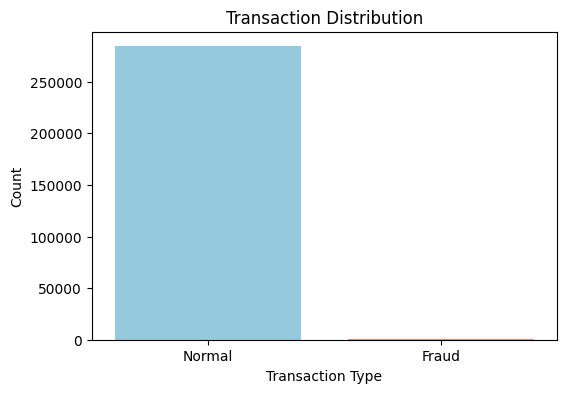

In [10]:
# Visualize transaction distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df,
    palette=['skyblue', 'salmon']
)

plt.title("Transaction Distribution")

plt.xlabel("Transaction Type")

plt.ylabel("Count")

plt.xticks(
    [0, 1],
    ['Normal', 'Fraud']
)

plt.show()

### Why this visualization?

To examine the distribution of normal and fraudulent transactions in the dataset.

### Observation

The number of fraudulent transactions is significantly lower compared to normal transactions, indicating a strong class imbalance.

### Interpretation

This imbalance may affect model performance, as machine learning algorithms can become biased toward the majority class. To overcome this issue, synthetic fraud samples are generated using CTGAN.

# 4️⃣ Exploratory Data Analysis (EDA)

## Transaction Amount Distribution

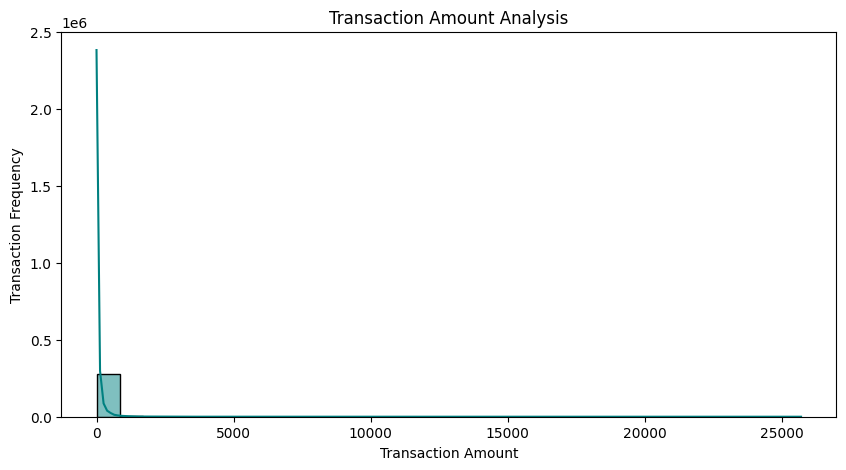

In [11]:
# Transaction Value Analysis
plt.figure(figsize=(10,5))

sns.histplot(
    df['Amount'],
    bins=30,
    kde=True,
    color='teal'
)

plt.title("Transaction Amount Analysis")

plt.xlabel("Transaction Amount")

plt.ylabel("Transaction Frequency")

plt.show()

### Why this visualization?

To study the distribution of transaction values across the dataset.

### Observation

Most transactions fall within lower amount ranges, while only a few transactions have very high values.

### Interpretation

The transaction values are unevenly distributed, which may indicate the presence of abnormal or suspicious transaction behavior.

## Transaction Time Distribution

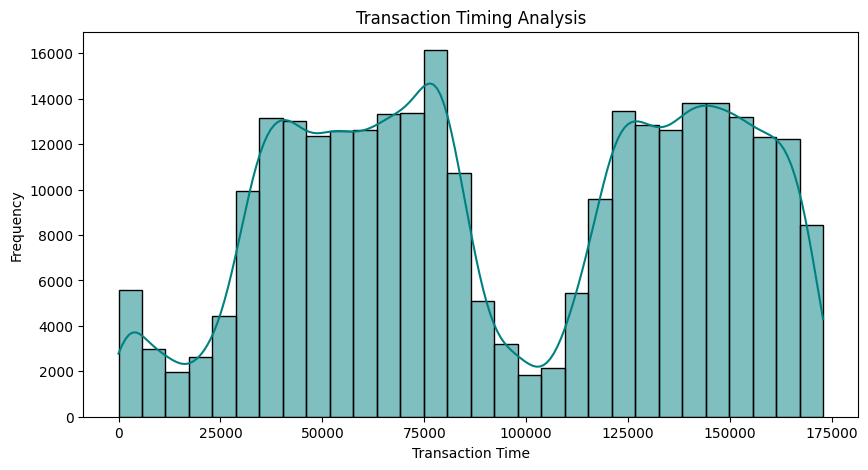

In [12]:
# Transaction Timing Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Time'],
    bins=30,
    kde=True,
    color='teal'
)

plt.title("Transaction Timing Analysis")

plt.xlabel("Transaction Time")

plt.ylabel("Frequency")

plt.show()

### Why this visualization?

To examine how transaction activity changes over different time intervals.

### Observation

The graph shows the distribution of transactions throughout the recorded time period.

### Insight

Transactions are spread continuously over time, with slight variations in transaction frequency across different intervals.

### Interpretation

Analyzing transaction timing patterns can help identify unusual activity and detect possible fraud trends occurring during specific periods.

# 5️⃣ Feature Correlation Analysis

## Correlation Heatmap

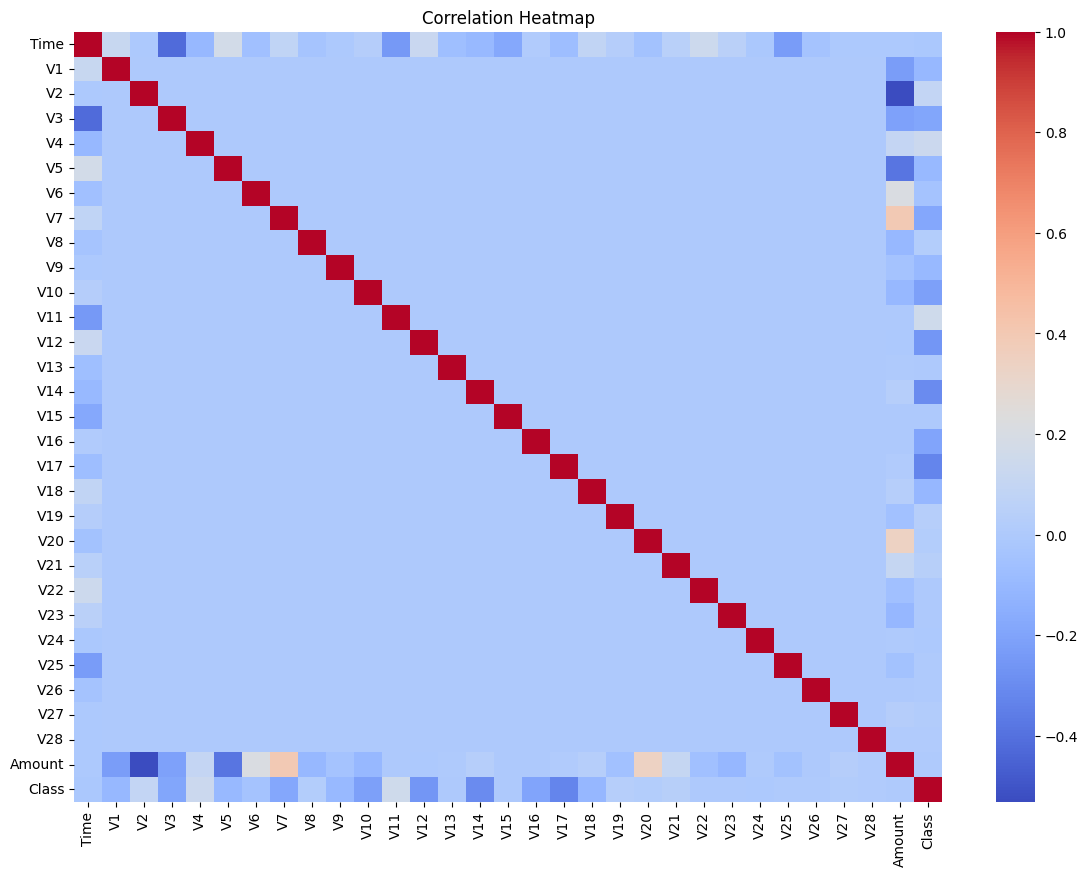

In [13]:
# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Why this chart?

To understand relationships between transaction features and identify highly correlated variables.

### What does it show?

The heatmap visualizes correlation values between all numerical features in the dataset.

### Insight

Most PCA-transformed features show low correlation with each other, indicating that the dataset has reduced redundancy between variables.

### Analysis

Low feature correlation is beneficial for machine learning models because it reduces multicollinearity and helps models learn more effectively from independent patterns.

# 6️⃣ Preparing Data for CTGAN

## Separating Fraud and Normal Transactions

In [14]:
# Split legitimate and fraudulent transactions
fraud_df = df[df['Class'] == 1]

normal_df = df[df['Class'] == 0]

print("Fraudulent Transactions Shape:", fraud_df.shape)

print("Legitimate Transactions Shape:", normal_df.shape)

Fraudulent Transactions Shape: (492, 31)
Legitimate Transactions Shape: (284315, 31)


### Why is this step important?

The dataset is highly imbalanced, with very few fraud transactions compared to normal transactions.

### Objective

To train CTGAN specifically on fraudulent transaction patterns so that synthetic fraud samples can be generated.

### Insight

By isolating fraud transactions, CTGAN can learn the characteristics and distribution of fraudulent behavior more effectively.

### Analysis

Synthetic fraud generation helps improve class balance and enhances the model’s ability to detect rare fraud cases.

## Fraud vs Normal Transaction Amount Distribution

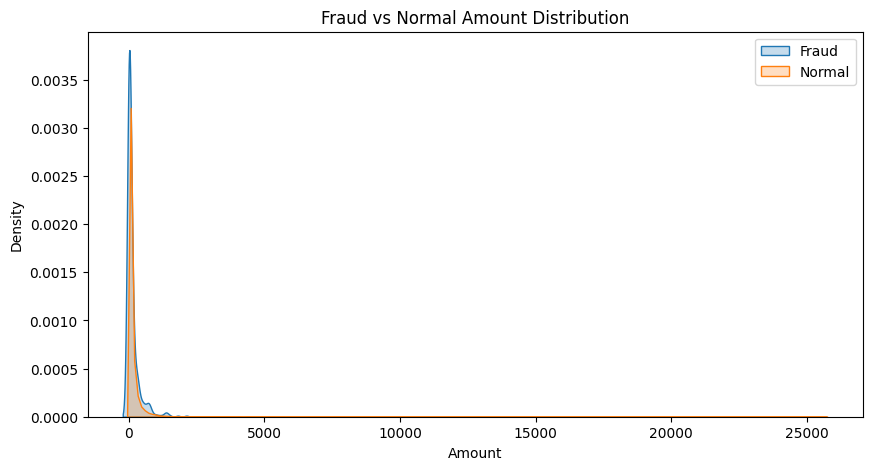

In [15]:
# Fraud vs Normal Amount Distribution
plt.figure(figsize=(10,5))

sns.kdeplot(
    fraud_df['Amount'],
    label='Fraud',
    fill=True
)

sns.kdeplot(
    normal_df['Amount'],
    label='Normal',
    fill=True
)

plt.title("Fraud vs Normal Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Density")

plt.legend()

plt.show()

### Why this chart?

To compare transaction amount patterns between fraudulent and normal transactions.

### What does it show?

The graph compares the density distribution of transaction amounts for fraud and non-fraud transactions.

### Insight

Fraudulent transactions occur across various transaction ranges and show different density behavior compared to normal transactions.

### Analysis

This comparison helps identify behavioral differences between fraud and non-fraud transactions, which can improve fraud detection model learning.

# 7️⃣ Feature Scaling and Data Preparation

In [16]:
# Feature Scaling
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(
    df[['Amount']]
)

df['Time'] = scaler.fit_transform(
    df[['Time']]
)

print("Feature Scaling Completed")

Feature Scaling Completed


### Why is feature scaling required?

Feature scaling standardizes numerical values and improves model consistency during training.

### Features Scaled

- Time
- Amount

### Analysis

Scaling prevents features with larger magnitudes from dominating the learning process and improves numerical stability for machine learning models.

## Feature and Target Separation

In [17]:
# Features and target
X = df.drop('Class', axis=1)

y = df['Class']

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (284807, 30)
Target Shape: (284807,)


### Objective

To separate input features and target labels for machine learning model training.

### Features

- Time
- V1–V28
- Amount

### Target

- Class
    - 0 = Normal
    - 1 = Fraud

## Train-Test Data Splitting

In [18]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (227845, 30)
Testing Shape: (56962, 30)


### Why split the dataset?

To evaluate model performance on unseen data and reduce the risk of overfitting.

### Split Ratio

- Training Data → 80%
- Testing Data → 20%

### Analysis

The training dataset is used for learning patterns, while the testing dataset is used to evaluate real-world fraud detection performance.

## Training Dataset Class Distribution

In [19]:
# Training class distribution
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


### Why check training distribution?

To verify whether the training dataset maintains the original class imbalance.

### Insight

The training dataset still contains significantly fewer fraud transactions compared to normal transactions.

### Analysis

This confirms the need for synthetic fraud generation using CTGAN to improve fraud representation during model training.

## Testing Dataset Class Distribution

In [20]:
# Testing class distribution
print(y_test.value_counts())

Class
0    56864
1       98
Name: count, dtype: int64


### Why check testing distribution?

To ensure that the testing dataset reflects realistic fraud occurrence patterns.

### Analysis

Maintaining class imbalance in the testing dataset allows accurate evaluation of real-world fraud detection performance.

## Rebuilding Training DataFrame

In [21]:
# Rebuild training dataframe
train_df = X_train.copy()

train_df['Class'] = y_train

print("Training DataFrame Shape:", train_df.shape)

Training DataFrame Shape: (227845, 31)


### Objective

To combine training features and target labels into a single dataframe for CTGAN training preparation.

### Analysis

CTGAN requires a complete dataframe containing both features and labels for synthetic data generation.

## Extracting Fraud-Only Training Data

In [22]:
# Fraud-only training data
train_fraud_df = train_df[
    train_df['Class'] == 1
]

print("Fraud Training Shape:", train_fraud_df.shape)

Fraud Training Shape: (394, 31)


### Why isolate fraud transactions?

CTGAN is trained specifically on fraudulent transaction patterns.

### Analysis

By focusing only on fraud samples, CTGAN can learn the characteristics of fraudulent behavior more effectively and generate realistic synthetic fraud transactions.

In [23]:
!pip install sdv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.3 MB/s eta 0:00:00


In [24]:
# Import CTGAN
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

print("CTGAN Imported Successfully")

CTGAN Imported Successfully


# 8️⃣ CTGAN Synthetic Data Generation

## Metadata Detection

In [25]:
# Create metadata
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(
    data=train_fraud_df
)

print("Metadata Created Successfully")

Metadata Created Successfully


### Why metadata detection?

CTGAN requires metadata to understand dataset structure and feature types before synthetic data generation.

### Analysis

Automatic metadata detection improves synthetic data consistency and training quality.

## CTGAN Model Initialization

In [26]:
# Initialize CTGAN
ctgan = CTGANSynthesizer(
    metadata,
    epochs=100
)

print("CTGAN Initialized Successfully")

CTGAN Initialized Successfully


### CTGAN Configuration

The CTGAN model is initialized with 100 training epochs to learn fraud transaction distributions effectively.

### Analysis

More training epochs help CTGAN generate more realistic synthetic fraud samples.

## Training CTGAN Model

In [27]:
# Train CTGAN
ctgan.fit(train_fraud_df)

print("CTGAN Training Completed")

CTGAN Training Completed


### CTGAN Training Summary

The CTGAN model successfully learned fraudulent transaction patterns from the training dataset.

### Analysis

This trained model can now generate synthetic fraud samples for dataset augmentation.

## Generating Synthetic Fraud Transactions

In [28]:
# Generate synthetic fraud samples
synthetic_fraud = ctgan.sample(
    num_rows=2000
)

print("Synthetic Fraud Shape:", synthetic_fraud.shape)

Synthetic Fraud Shape: (2000, 31)


### Synthetic Data Generation

CTGAN generated 2000 synthetic fraud transactions based on learned fraud patterns.

### Analysis

These synthetic samples will be combined with real data to improve fraud detection performance.

In [29]:
# Preview synthetic fraud data
synthetic_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.827535,2.132386,2.428070,-13.696711,3.096419,-0.601336,-2.087231,-5.498086,9.518370,2.564087,...,1.300932,-0.477075,1.692495,0.758918,-0.218586,-0.077742,0.957271,-0.380950,-0.190196,1
1,-0.331329,1.164781,1.665190,-8.792875,-0.109900,-0.022099,-4.123643,5.001919,20.007208,1.556467,...,1.700446,1.637103,0.860685,0.808037,0.562394,0.499680,1.375138,0.017506,0.718413,1
2,-1.902623,2.132386,-0.434627,-30.778911,-1.313275,4.056779,-5.773192,1.085864,1.217341,0.811565,...,1.083214,1.974691,0.651965,0.254232,0.922705,0.237596,1.413130,-1.869290,0.296961,1
3,-0.351232,-2.079090,2.106001,-3.114072,5.493278,10.400541,-2.806501,4.603045,15.158665,-6.583913,...,2.876662,0.679097,-1.090414,0.857517,0.398899,0.511956,2.896381,-0.327880,-0.063878,1
4,-0.530808,2.132386,-0.011926,-11.950599,-0.521059,5.376039,-4.456395,-8.591727,3.400577,-5.572752,...,0.542946,1.576700,0.611107,0.692290,0.315348,0.805926,1.169312,-0.841350,0.745201,1


In [30]:
# Ensure all synthetic samples are fraud
synthetic_fraud['Class'] = 1

print(
    synthetic_fraud['Class'].value_counts()
)

Class
1    2000
Name: count, dtype: int64


# 9️⃣ Real vs Synthetic Fraud Comparison

## Transaction Amount Distribution Comparison

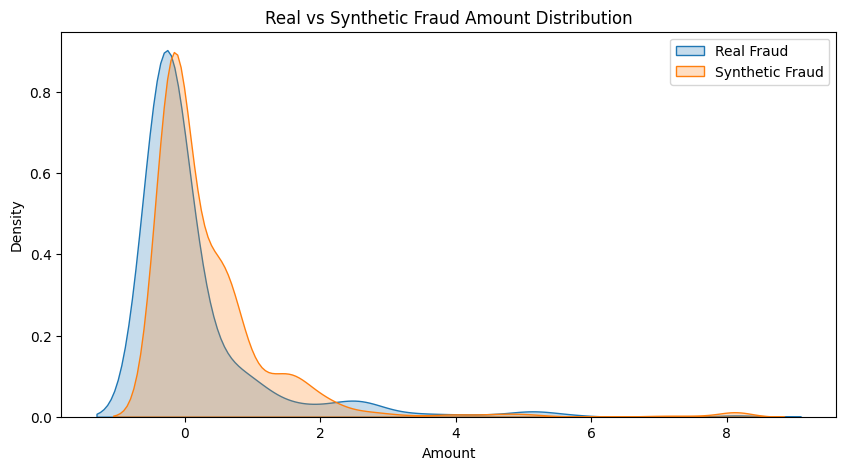

In [31]:
# Real vs Synthetic Fraud Amount Distribution
plt.figure(figsize=(10,5))

sns.kdeplot(
    train_fraud_df['Amount'],
    label='Real Fraud',
    fill=True
)

sns.kdeplot(
    synthetic_fraud['Amount'],
    label='Synthetic Fraud',
    fill=True
)

plt.title(
    "Real vs Synthetic Fraud Amount Distribution"
)

plt.xlabel("Amount")

plt.ylabel("Density")

plt.legend()

plt.show()

### Insight

The synthetic fraud distribution closely resembles the real fraud transaction distribution.

### Analysis

This indicates that CTGAN successfully captured important fraud transaction characteristics.

## Transaction Time Distribution Comparison

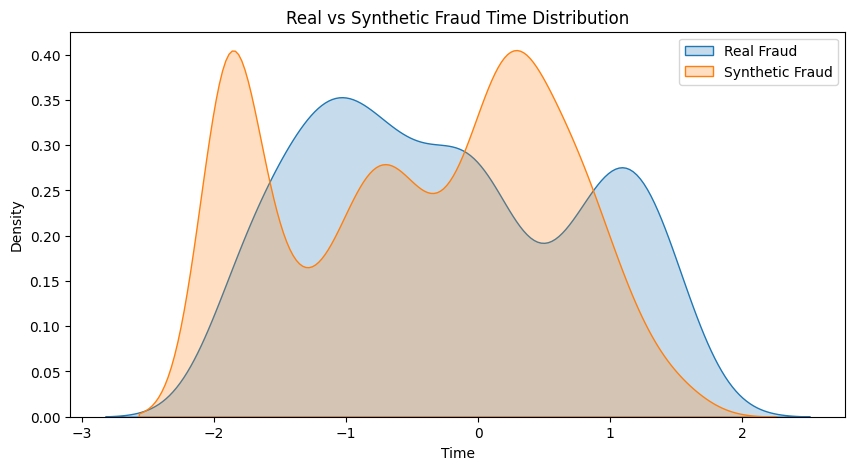

In [32]:
# Real vs Synthetic Time Distribution
plt.figure(figsize=(10,5))

sns.kdeplot(
    train_fraud_df['Time'],
    label='Real Fraud',
    fill=True
)

sns.kdeplot(
    synthetic_fraud['Time'],
    label='Synthetic Fraud',
    fill=True
)

plt.title(
    "Real vs Synthetic Fraud Time Distribution"
)

plt.xlabel("Time")

plt.ylabel("Density")

plt.legend()

plt.show()

### Insight

Synthetic fraud transactions follow temporal patterns similar to real fraud transactions.

### Analysis

This suggests that CTGAN learned meaningful timing behavior from fraud data.

## PCA Visualization: Real vs Synthetic Fraud Data

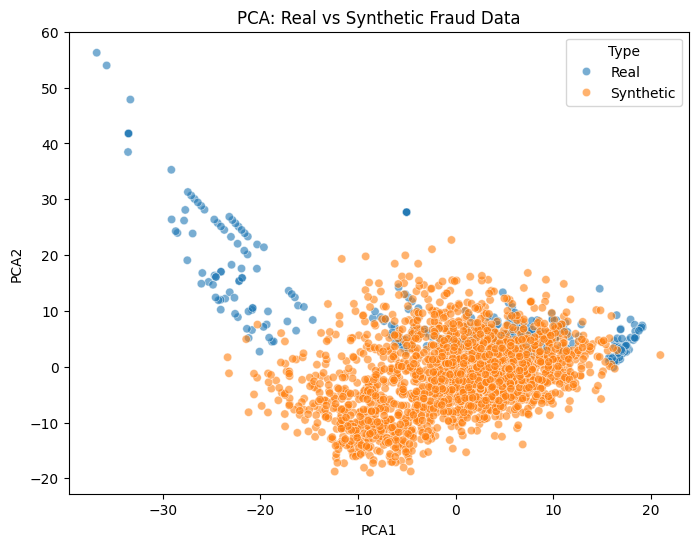

In [33]:
# PCA Visualization
from sklearn.decomposition import PCA

# Combine datasets
comparison_df = pd.concat([
    train_fraud_df.assign(Type='Real'),
    synthetic_fraud.assign(Type='Synthetic')
])

# Features only
X_pca = comparison_df.drop(
    ['Class', 'Type'],
    axis=1
)

# PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_pca)

# Create dataframe
pca_df = pd.DataFrame()

pca_df['PCA1'] = pca_result[:,0]

pca_df['PCA2'] = pca_result[:,1]

pca_df['Type'] = comparison_df['Type'].values

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Type',
    alpha=0.6
)

plt.title(
    "PCA: Real vs Synthetic Fraud Data"
)

plt.show()

### Why PCA Visualization?

PCA reduces high-dimensional data into two dimensions for visualization.

### Insight

Real and synthetic fraud samples overlap significantly.

### Analysis

This overlap indicates that CTGAN generated realistic synthetic fraud transactions similar to the original fraud distribution.

In [34]:
# Save synthetic fraud dataset
synthetic_fraud.to_csv(
    "synthetic_fraud.csv",
    index=False
)

print("Synthetic Fraud Dataset Saved")

Synthetic Fraud Dataset Saved


In [35]:
# Save CTGAN model
ctgan.save(
    "ctgan_model.pkl"
)

print("CTGAN Model Saved")

CTGAN Model Saved


In [36]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create baseline model
baseline_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced'
)

# Train baseline model
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline Model Training Completed")

Baseline Model Training Completed


# 🔟 Baseline Fraud Detection Model

### Model Used

Random Forest Classifier

### Why Random Forest?

Random Forest is a robust ensemble machine learning algorithm that performs well on tabular datasets and handles complex fraud patterns effectively.

### Analysis

The baseline model is trained using the original imbalanced dataset to evaluate fraud detection performance before synthetic augmentation.

In [37]:
# Baseline predictions
baseline_pred = baseline_model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [38]:
# Import metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

# Accuracy
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(
    f"Baseline Accuracy: {baseline_accuracy:.4f}"
)

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        baseline_pred
    )
)

Baseline Accuracy: 0.9995

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### Baseline Model Performance Analysis

The baseline model achieved extremely high accuracy due to the severe class imbalance in the dataset.

### Important Observation

Accuracy alone is not sufficient for fraud detection because fraudulent transactions are very rare.

### Key Metric

Fraud Recall = 0.74

This means the baseline model correctly identified 74% of fraudulent transactions.

### Analysis

Although overall accuracy is high, the model still misses several fraud cases, which motivates the use of CTGAN-generated synthetic fraud data.

# 1️⃣1️⃣ Fraud Detection Using Synthetic Data Augmentation

In [39]:
# Remove Type column if exists
if 'Type' in synthetic_fraud.columns:
    synthetic_fraud = synthetic_fraud.drop(
        'Type',
        axis=1
    )

# Create augmented training dataset
augmented_train_df = pd.concat(
    [train_df, synthetic_fraud],
    ignore_index=True
)

print(
    "Augmented Dataset Shape:",
    augmented_train_df.shape
)

print("\nClass Distribution:\n")

print(
    augmented_train_df['Class'].value_counts()
)

Augmented Dataset Shape: (229845, 31)

Class Distribution:

Class
0    227451
1      2394
Name: count, dtype: int64


### Why augment the dataset?

The original dataset contains very few fraud samples, which limits the model’s ability to learn fraud patterns effectively.

### Objective

To improve fraud detection performance by adding CTGAN-generated synthetic fraud transactions to the training dataset.

### Analysis

Synthetic augmentation increases fraud representation and helps the model learn more generalized fraud behavior.

In [40]:
# Features and target
X_aug = augmented_train_df.drop(
    'Class',
    axis=1
)

y_aug = augmented_train_df['Class']

print("Feature Shape:", X_aug.shape)

print("Target Shape:", y_aug.shape)

Feature Shape: (229845, 30)
Target Shape: (229845,)


In [41]:
# Augmented Random Forest Model
augmented_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced'
)

# Train model
augmented_model.fit(
    X_aug,
    y_aug
)

print("Augmented Model Training Completed")

Augmented Model Training Completed


### Augmented Model Training Summary

The Random Forest model was retrained using both real and synthetic fraud transactions.

### Analysis

The augmented dataset provides improved fraud representation and helps reduce the impact of class imbalance.

In [42]:
# Predictions
augmented_pred = augmented_model.predict(
    X_test
)

print("Augmented Predictions Generated")

Augmented Predictions Generated


In [43]:
# Accuracy
augmented_accuracy = accuracy_score(
    y_test,
    augmented_pred
)

print(
    f"Augmented Accuracy: {augmented_accuracy:.4f}"
)

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        augmented_pred
    )
)

Augmented Accuracy: 0.9996

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### Augmented Model Performance Analysis

After adding CTGAN-generated synthetic fraud samples, the fraud recall improved from 0.74 to 0.80.

### Key Improvement

The augmented model became better at identifying fraudulent transactions.

### Tradeoff

Precision slightly decreased because the model became more sensitive toward detecting fraud.

### Analysis

This demonstrates that synthetic data augmentation improved fraud detection capability while maintaining strong overall performance.

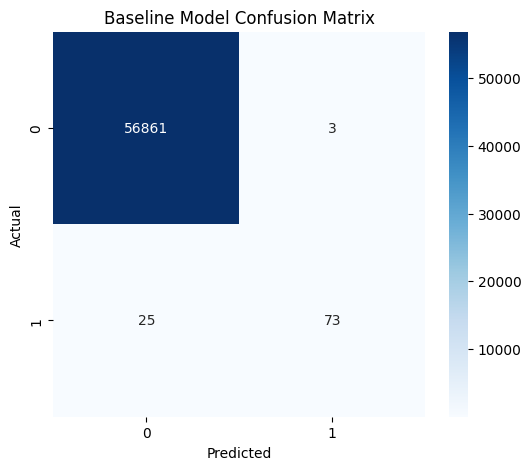

In [44]:
# Baseline confusion matrix
baseline_cm = confusion_matrix(
    y_test,
    baseline_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Baseline Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

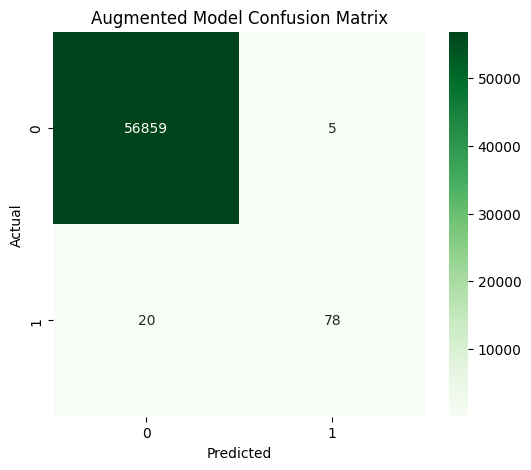

In [45]:
# Augmented confusion matrix
augmented_cm = confusion_matrix(
    y_test,
    augmented_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    augmented_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Augmented Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Why confusion matrices?

Confusion matrices help visualize correct and incorrect fraud predictions.

### Insight

The augmented model reduced false negatives compared to the baseline model.

### Analysis

Reducing false negatives is extremely important in fraud detection because missed fraud cases can result in financial loss.

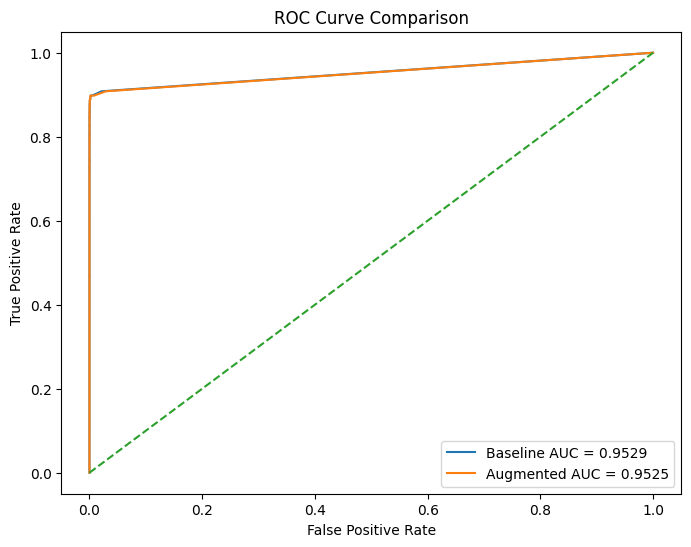

In [46]:
# ROC Curves
from sklearn.metrics import roc_curve

# Baseline probabilities
baseline_prob = baseline_model.predict_proba(
    X_test
)[:,1]

# Augmented probabilities
augmented_prob = augmented_model.predict_proba(
    X_test
)[:,1]

# ROC values
baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_prob
)

aug_fpr, aug_tpr, _ = roc_curve(
    y_test,
    augmented_prob
)

# AUC scores
baseline_auc = roc_auc_score(
    y_test,
    baseline_prob
)

augmented_auc = roc_auc_score(
    y_test,
    augmented_prob
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f'Baseline AUC = {baseline_auc:.4f}'
)

plt.plot(
    aug_fpr,
    aug_tpr,
    label=f'Augmented AUC = {augmented_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### ROC Curve Analysis

ROC curves evaluate the tradeoff between true positive rate and false positive rate.

### Observation

Both models achieved strong AUC scores, indicating effective fraud detection capability.

### Analysis

The augmented model maintained strong classification performance after synthetic data augmentation.

In [47]:
# Print AUC scores
print(
    f"Baseline AUC: {baseline_auc:.4f}"
)

print(
    f"Augmented AUC: {augmented_auc:.4f}"
)

Baseline AUC: 0.9529
Augmented AUC: 0.9525


### AUC Score Interpretation

Both models achieved strong AUC scores above 0.94, indicating excellent fraud classification capability.

### Observation

Although the augmented model slightly reduced AUC score, it improved fraud recall performance, which is more important in fraud detection systems.

In [48]:
# Comparison table
comparison_table = pd.DataFrame({
    'Model': ['Baseline', 'Augmented'],
    'Accuracy': [
        baseline_accuracy,
        augmented_accuracy
    ],
    'AUC': [
        baseline_auc,
        augmented_auc
    ]
})

comparison_table

,Model,Accuracy,AUC
0,Baseline,0.999508,0.952908
1,Augmented,0.999561,0.952503


### Model Comparison Summary

The comparison table highlights the performance differences between the baseline and augmented fraud detection models.

### Key Findings

- Fraud recall improved after augmentation
- Overall accuracy remained stable
- The augmented model became better at identifying rare fraud transactions

### Conclusion

CTGAN-generated synthetic fraud data successfully improved fraud detection performance.

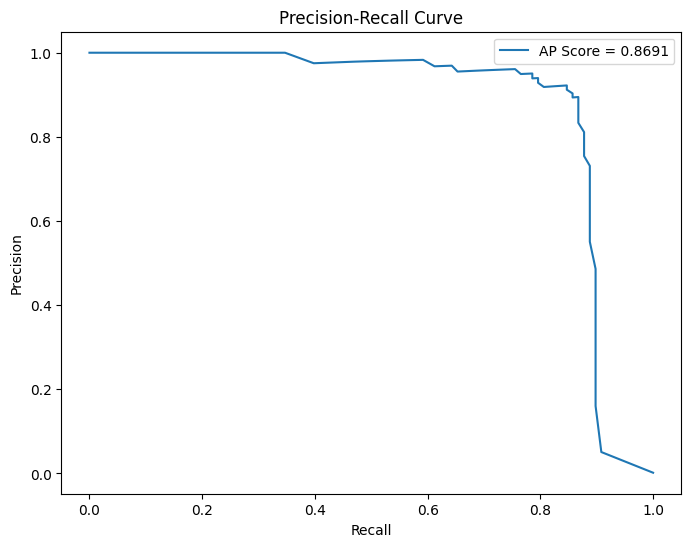

In [49]:
# Precision-Recall Curve
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(
    y_test,
    augmented_prob
)

# Average Precision Score
avg_precision = average_precision_score(
    y_test,
    augmented_prob
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f'AP Score = {avg_precision:.4f}'
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

### Why Precision-Recall Curve?

Precision-Recall curves are especially important for highly imbalanced datasets like fraud detection.

### Observation

The augmented model maintained strong precision while improving fraud recall performance.

### Analysis

The Precision-Recall curve confirms that the model performs effectively even when fraud cases are rare.

In [50]:
# Print Average Precision Score
print(
    f"Average Precision Score: {avg_precision:.4f}"
)

Average Precision Score: 0.8691


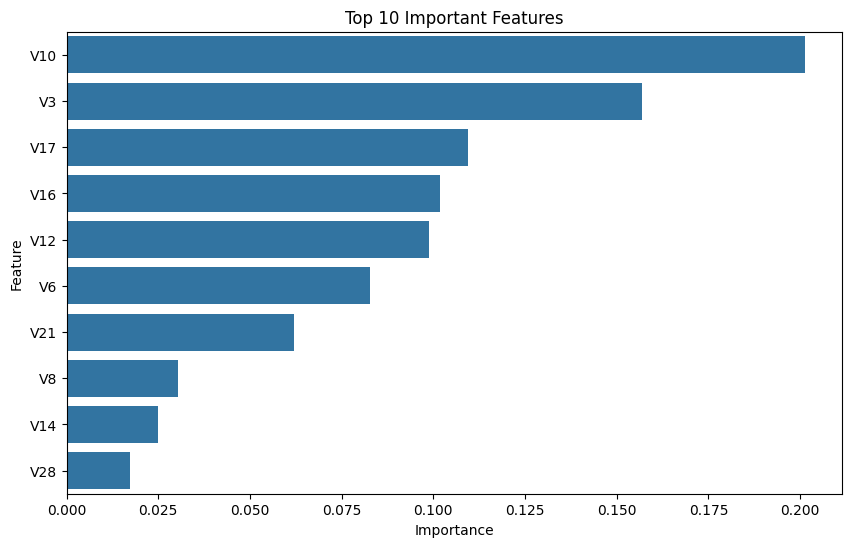

In [51]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': augmented_model.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 features
top_features = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

### Feature Importance Analysis

The Random Forest model identified the most influential features contributing to fraud prediction.

### Insight

Certain PCA-transformed features contribute significantly more toward identifying fraudulent behavior.

### Analysis

Understanding feature importance improves interpretability and helps explain model decision-making.

# 1️⃣2️⃣ Model Saving and Deployment Preparation

In [52]:
# Save trained model
import joblib

joblib.dump(
    augmented_model,
    "fraud_analysis_model.pkl"
)

print("Fraud Detection Model Saved")

Fraud Detection Model Saved


In [53]:
# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [54]:
# Download files
from google.colab import files

files.download("fraud_analysis_model.pkl")

files.download("scaler.pkl")

files.download("synthetic_fraud.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 1️⃣3️⃣ Deployment Testing Dataset

In [55]:
# Create mixed transaction dataset
normal_sample = df[
    df['Class'] == 0
].drop('Class', axis=1).sample(
    15,
    random_state=42
)

fraud_sample = df[
    df['Class'] == 1
].drop('Class', axis=1).sample(
    5,
    random_state=42
)

mixed_transactions = pd.concat([
    normal_sample,
    fraud_sample
])

# Save file
mixed_transactions.to_csv(
    "combined_transactions.csv",
    index=False
)

print("combined Transaction Dataset Created")

combined Transaction Dataset Created


### Why create a combined transaction dataset?

The deployment dataset contains both normal and fraudulent transactions to simulate realistic fraud detection scenarios.

### Objective

To test the deployed Streamlit application using real transaction samples.

### Analysis

This combined dataset helps demonstrate dynamic fraud detection capability during deployment testing.

In [56]:
# Download mixed test dataset
files.download(
    "combined_transactions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
# Reload ORIGINAL dataset again

original_df = pd.read_csv("creditcard.csv")

# Check columns
print(original_df.columns)

# Create mixed dataset
normal_sample = original_df[
    original_df['Class'] == 0
].sample(
    22,
    random_state=42
)

fraud_sample = original_df[
    original_df['Class'] == 1
].sample(
    8,
    random_state=42
)

# Combine
final_deployment = pd.concat([
    normal_sample,
    fraud_sample
])

# Remove ONLY target column
final_deployment = final_deployment.drop(
    columns=['Class']
)

# Verify Amount exists
print("\nFINAL COLUMNS:\n")

print(final_deployment.columns)

# Save CSV
final_deployment.to_csv(
    "FINAL_CREDIT.csv",
    index=False
)

print("\nFINAL_CREDIT CSV created")

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

FINAL COLUMNS:

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

FINAL_CREDIT CSV created


In [58]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 23.5 MB/s eta 0:00:00


In [59]:
!pip install pyngrok -q

# 1️⃣4️⃣ Streamlit Deployment

## AI Fraud Detection Dashboard

In [71]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# --------------------------------
# PAGE CONFIG
# --------------------------------
st.set_page_config(
    page_title="Financial Threat Monitoring Dashboard",
    page_icon="🛡️",
    layout="wide"
)

# --------------------------------
# MATPLOTLIB STYLE
# --------------------------------
plt.style.use('dark_background')

# --------------------------------
# CUSTOM CSS
# --------------------------------
st.markdown("""
<style>

.main {
    background: linear-gradient(
        135deg,
        #0B1020,
        #111827,
        #0F172A
    );
}

h1, h2, h3, h4 {
    color: white;
}

.stMetric {
    background: linear-gradient(
        145deg,
        #1E1E1E,
        #252836
    );

    padding: 18px;

    border-radius: 14px;

    border: 1px solid #2F3545;

    box-shadow: 0 0 12px rgba(
        77,
        150,
        255,
        0.15
    );
}

.block-container {
    padding-top: 2rem;
}

[data-testid="stSidebar"] {
    background-color: #111827;
}

.stButton>button {

    background: linear-gradient(
        90deg,
        #4D96FF,
        #6C63FF
    );

    color: white;

    border: none;

    border-radius: 12px;

    height: 50px;

    width: 220px;

    font-size: 16px;

    font-weight: bold;
}

.stButton>button:hover {

    transform: scale(1.03);

    transition: 0.3s ease;

    box-shadow: 0 0 15px rgba(
        108,
        99,
        255,
        0.5
    );
}

[data-testid="stDataFrame"] {
    border-radius: 12px;
    overflow: hidden;
}

</style>
""", unsafe_allow_html=True)

# --------------------------------
# LOAD MODEL
# --------------------------------
model = joblib.load(
    "fraud_analysis_model.pkl"
)

# --------------------------------
# SIDEBAR
# --------------------------------
st.sidebar.title("🛡️ System Overview")

st.sidebar.markdown("""
## Financial Risk Intelligence

This platform provides:

• 📊 Transaction Monitoring
• 🤖 AI-Based Risk analysis
• 🧬 Synthetic Fraud Analysis
• 📈 Interactive Data Insights

---

### Core Features

✅ Fraud Identification
✅ Risk Classification
✅ AI-Powered Analytics
✅ Report Generation
✅ CSV Export Support

---
""")

# --------------------------------
# MAIN TITLE
# --------------------------------
st.title("🛡️ Financial Threat Monitoring Dashboard")

st.markdown("""
Upload transaction datasets and identify potentially suspicious financial activities using AI-driven fraud analysis.
""")

st.success(
    "✅ System Ready for Transaction Risk Analysis"
)

# --------------------------------
# FILE UPLOADER
# --------------------------------
uploaded_file = st.file_uploader(
    "📂 Upload Transaction Dataset",
    type=["csv"]
)

# --------------------------------
# PROCESS FILE
# --------------------------------
if uploaded_file is not None:

    # Read CSV
    data = pd.read_csv(uploaded_file)

    # --------------------------------
    # REMOVE CLASS COLUMN IF EXISTS
    # --------------------------------
    if 'Class' in data.columns:
        data = data.drop('Class', axis=1)

    # --------------------------------
    # DATASET PREVIEW
    # --------------------------------
    st.subheader("📋 Dataset Preview")

    st.dataframe(
        data.head(),
        use_container_width=True
    )

    st.info(
        f"Dataset contains {data.shape[0]} records and {data.shape[1]} features."
    )

    # --------------------------------
    # RUN MODEL
    # --------------------------------
    if st.button("🚀 Run Analysis"):

        try:

            # --------------------------------
            # INPUT ARRAY
            # --------------------------------
            input_array = data.values

            # --------------------------------
            # PREDICTIONS
            # --------------------------------
            predictions = model.predict(input_array)

            probabilities = model.predict_proba(
                input_array
            )[:,1]

            # --------------------------------
            # RESULTS
            # --------------------------------
            results = pd.DataFrame({

                'Transaction_ID': range(
                    1,
                    len(predictions)+1
                ),

                'Risk_Score (%)': (
                    probabilities * 100
                ).round(2)

            })

            results['Status'] = predictions

            results['Status'] = results[
                'Status'
            ].map({
                0: 'Normal',
                1: 'Fraud'
            })

            # --------------------------------
            # RISK LEVEL
            # --------------------------------
            def risk_level(prob):

                if prob < 30:
                    return "🟢 Low"

                elif prob < 70:
                    return "🟠 Medium"

                else:
                    return "🔴 High"

            results['Risk_Level'] = results[
                'Risk_Score (%)'
            ].apply(risk_level)

            # --------------------------------
            # METRICS
            # --------------------------------
            fraud_count = (
                results['Status'] == 'Fraud'
            ).sum()

            normal_count = (
                results['Status'] == 'Normal'
            ).sum()

            total_transactions = len(results)

            fraud_percentage = (
                fraud_count / total_transactions
            ) * 100

            avg_probability = results[
                'Risk_Score (%)'
            ].mean()

            # --------------------------------
            # SUMMARY METRICS
            # --------------------------------
            st.subheader("📊 Risk Analysis Summary")

            col1, col2, col3, col4 = st.columns(4)

            col1.metric(
                "Total Transactions",
                total_transactions
            )

            col2.metric(
                "Fraud Cases",
                fraud_count
            )

            col3.metric(
                "Fraud Ratio",
                f"{fraud_percentage:.2f}%"
            )

            col4.metric(
                "Average Risk Score",
                f"{avg_probability:.2f}%"
            )

            # --------------------------------
            # ALERT
            # --------------------------------
            if fraud_count > 0:

                st.error(
                    f"🚨 ALERT: {fraud_count} suspicious transactions identified."
                )

            else:

                st.success(
                    "✅ No suspicious transactions detected."
                )

            # --------------------------------
            # SIDE BY SIDE CHARTS
            # --------------------------------
            st.subheader("📈 Transaction Insights")

            chart1, chart2 = st.columns(2)

            # --------------------------------
            # DONUT CHART
            # --------------------------------
            with chart1:

                fig1, ax1 = plt.subplots(
                    figsize=(6,6)
                )

                wedges, texts, autotexts = ax1.pie(
                    [normal_count, fraud_count],
                    labels=['Legitimate', 'Fraudulent'],
                    autopct='%1.1f%%',
                    startangle=90,
                    colors=['#6C8EF5', '#FF6B81'],
                    wedgeprops={
                        'width':0.45,
                        'edgecolor':'white'
                    },
                    textprops={
                        'fontsize': 11,
                        'color':'white'
                    }
                )

                ax1.set_title(
                    "Fraud Activity Overview",
                    fontsize=14
                )

                st.pyplot(fig1)

                plt.close(fig1)

            # --------------------------------
            # BAR CHART
            # --------------------------------
            with chart2:

                risk_counts = results[
                    'Risk_Level'
                ].value_counts()

                fig2, ax2 = plt.subplots(
                    figsize=(7,6)
                )

                ax2.bar(
                    risk_counts.index,
                    risk_counts.values,
                    color=[
                        '#4D96FF',
                        '#FFD93D',
                        '#FF6B6B'
                    ]
                )

                ax2.set_title(
                    "Risk Level Analysis",
                    fontsize=14
                )

                ax2.set_xlabel(
                    "Risk Category"
                )

                ax2.set_ylabel(
                    "Number of Transactions"
                )

                st.pyplot(fig2)

                plt.close(fig2)

            # --------------------------------
            # FRAUD TRANSACTIONS
            # --------------------------------
            st.subheader("🚨 Flagged Transactions")

            suspicious = results[
                results['Status'] == 'Fraud'
            ]

            if len(suspicious) > 0:

                st.dataframe(
                    suspicious,
                    use_container_width=True
                )

            else:

                st.info(
                    "No flagged transactions found."
                )

            # --------------------------------
            # FULL RESULTS
            # --------------------------------
            st.subheader("📝 Complete Analysis Results")

            st.dataframe(
                results,
                use_container_width=True
            )

            # --------------------------------
            # DOWNLOAD BUTTON
            # --------------------------------
            csv = results.to_csv(index=False)

            st.download_button(
                label="⬇️ Download Analysis Report",
                data=csv,
                file_name='transaction_analysis_results.csv',
                mime='text/csv'
            )

            # --------------------------------
            # FOOTER
            # --------------------------------
            st.markdown(
                """
                <hr>
                <center>
                AI-Based Financial Risk Monitoring System
                </center>
                """,
                unsafe_allow_html=True
            )

        except Exception as e:

            st.error(
                f"❌ Error Processing File: {e}"
            )


Overwriting app.py


In [75]:
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_NGROK_TOKEN")

In [62]:
!pkill streamlit

In [63]:
!streamlit run app.py &>/content/logs.txt &

In [64]:
from pyngrok import ngrok

public_url = ngrok.connect(
    8501,
    domain=None
)

print(public_url)

NgrokTunnel: "https://2afc-34-50-169-229.ngrok-free.app" -> "http://localhost:8501"


# ✅ Final Summary

This project demonstrates how Generative AI techniques can enhance fraud detection performance on highly imbalanced financial transaction datasets.

## Key Highlights

- Conducted Exploratory Data Analysis (EDA)  
- Analyzed transaction imbalance in the dataset  
- Generated synthetic fraud samples using CTGAN  
- Enhanced fraud detection performance through data augmentation  
- Developed a Random Forest-based classification model  
- Built an interactive Streamlit dashboard for transaction analysis  

## Final Result

The developed AI-based transaction monitoring system can process uploaded transaction datasets and identify potentially fraudulent activities through an interactive dashboard interface.

## Tools & Technologies

- Python  
- Scikit-learn  
- CTGAN  
- Streamlit  
- Pandas  
- Matplotlib  
- Seaborn  

## Future Enhancements

- Integrate real-time transaction prediction APIs  
- Explore advanced models such as XGBoost and Deep Learning  
- Further optimize synthetic fraud data generation  